# Bộ đặc trưng HLG — Histogram + LBP + Geometric Ratios

| # | Đặc trưng | Phương pháp | Chiều vector |
|---|---|---|---|
| 1 | **Color Histogram** | HSV 3D histogram 8×8×8 bins, normalize L2 (Euclidean) → Unit vector | 512 |
| 2 | **LBP** | Local Binary Pattern P=8, R=1 → histogram 256 bins, chuẩn hóa tần suất | 256 |
| 3 | **Geometric Ratios** | 6 tỷ lệ hình học tính từ key landmarks (mắt, mũi, miệng, gò má) | 6 |

> Mỗi mục minh họa **TRƯỚC** (ảnh đầu vào) và **SAU** (đặc trưng trích xuất).

In [1]:
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from skimage.feature import local_binary_pattern
import mediapipe as mp

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'font.size': 9})

NOTEBOOK_DIR = Path('.').resolve()
IMG_SIZE = (200, 200)

DATASET_DIR = None
for _c in [
    NOTEBOOK_DIR / 'dataset' / 'MainData',
    NOTEBOOK_DIR / 'dataset' / 'FullData',
]:
    if _c.exists() and any(_c.glob('*.jpg')):
        DATASET_DIR = _c
        break

assert DATASET_DIR is not None, 'Khong tim thay dataset!'
print(f'Dataset: {DATASET_DIR}')
print(f'So anh: {len(list(DATASET_DIR.glob("*.jpg")))}')

Dataset: D:\HCSDLDPT\BTL_HCSDLDPT\HLG\dataset\MainData
So anh: 520


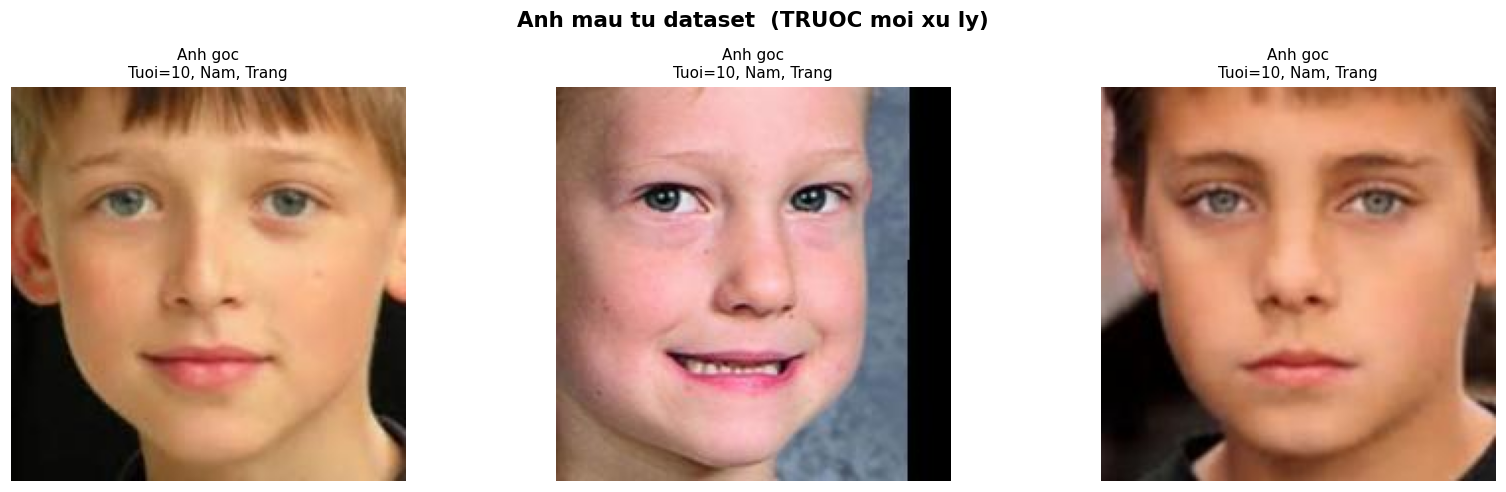

Kich thuoc goc: 200x200 px


In [2]:
# ---- Tai anh mau ----
sample_paths = sorted(DATASET_DIR.glob('*.jpg'))[:3]
samples = []
for p in sample_paths:
    img = cv2.imread(str(p))
    if img is not None:
        samples.append((p.name, img))

def parse_label(name):
    parts = name.split('_')
    if len(parts) < 3:
        return name[:25]
    gender = 'Nam' if parts[1] == '0' else 'Nu'
    race_map = {'0': 'Trang', '1': 'Den', '2': 'A Dong', '3': 'An Do', '4': 'Khac'}
    return f'Tuoi={parts[0]}, {gender}, {race_map.get(parts[2], "?")}'

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4.5))
if len(samples) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, samples):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Anh goc\n{parse_label(name)}', fontsize=10)
    ax.axis('off')
plt.suptitle('Anh mau tu dataset  (TRUOC moi xu ly)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Kich thuoc goc: {samples[0][1].shape[1]}x{samples[0][1].shape[0]} px')

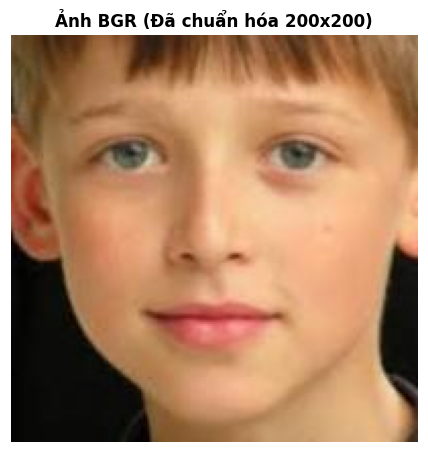

In [3]:
# Lấy ảnh đầu tiên từ danh sách samples đã tải của bạn
img0_bgr = samples[0][1]

# Tiến hành resize về chuẩn 200x200
img0_resized = cv2.resize(img0_bgr, (200, 200), interpolation=cv2.INTER_AREA)
img0_rgb = cv2.cvtColor(img0_resized, cv2.COLOR_BGR2RGB)

# plt.figure(figsize=(5, 5))
plt.imshow(img0_rgb)
plt.title('Ảnh BGR (Đã chuẩn hóa 200x200)', fontweight='bold')
plt.axis('off')
plt.show()

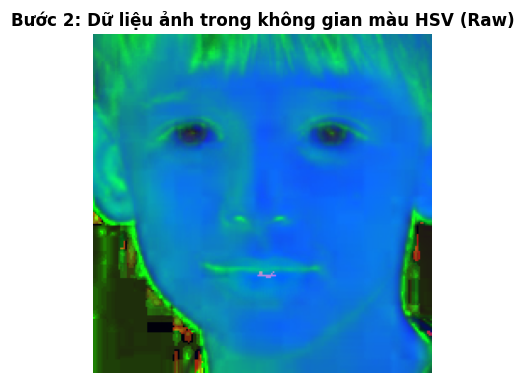

In [ ]:
# 1. Chuyển đổi sang không gian màu HSV
img0_hsv = cv2.cvtColor(img0_resized, cv2.COLOR_BGR2HSV)

# 2. Hiển thị gộp luôn
plt.figure(figsize=(4, 4))
plt.imshow(img0_hsv) 
plt.title('Bước 2: Dữ liệu ảnh trong không gian màu HSV', fontweight='bold')
plt.axis('off')
plt.show()

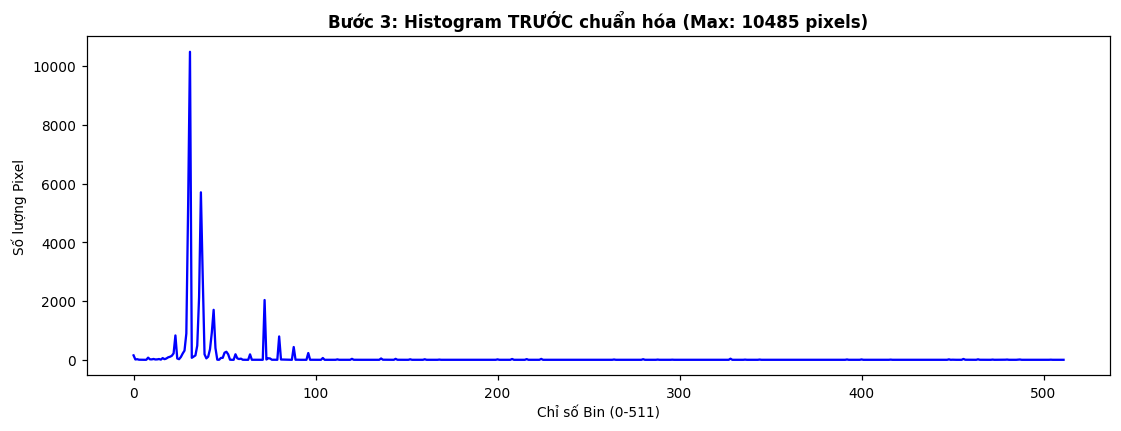

In [5]:
# 1. Tính toán Histogram 3D thô từ ảnh HSV
hist_3d_raw = cv2.calcHist(
    [img0_hsv], [0, 1, 2], None, 
    [8, 8, 8], [0, 180, 0, 256, 0, 256]
) #

# 2. Trải phẳng thành vector 512 chiều để hiển thị
raw_vector = hist_3d_raw.flatten() #

plt.figure(figsize=(12, 4))
plt.plot(raw_vector, color='blue')
plt.title(f'Bước 3: Histogram TRƯỚC chuẩn hóa (Max: {int(raw_vector.max())} pixels)', fontweight='bold')
plt.xlabel('Chỉ số Bin (0-511)')
plt.ylabel('Số lượng Pixel')
plt.show()

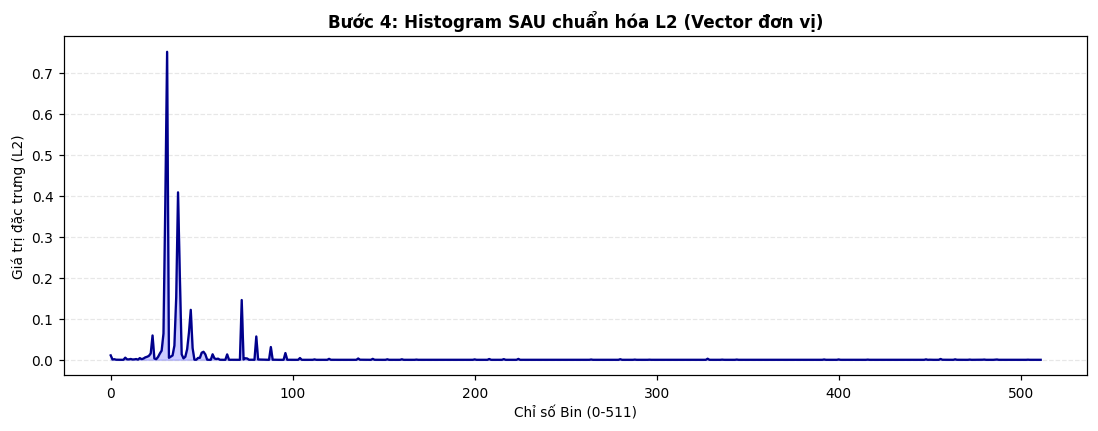

Kích thước vector: 512 chiều
Tổng bình phương các phần tử (L2 Check): 1.00


In [6]:
# 1. Chuẩn hóa L2 (Euclidean Norm)
# Lệnh này đưa độ dài vector về 1.0 (Unit Vector)
hist_3d_l2 = hist_3d_raw.copy()
cv2.normalize(hist_3d_l2, hist_3d_l2) # Mặc định là NORM_L2

# 2. Vector đặc trưng cuối cùng (512 chiều)
l2_vector = hist_3d_l2.flatten().astype(np.float64) #

plt.figure(figsize=(12, 4))
plt.plot(l2_vector, color='darkblue')
plt.fill_between(range(512), l2_vector, color='blue', alpha=0.2)
plt.title('Bước 4: Histogram SAU chuẩn hóa L2 (Vector đơn vị)', fontweight='bold')
plt.xlabel('Chỉ số Bin (0-511)')
plt.ylabel('Giá trị đặc trưng (L2)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Kiểm tra độ dài vector (L2 norm)
print(f"Kích thước vector: {len(l2_vector)} chiều") #
print(f"Tổng bình phương các phần tử (L2 Check): {np.sum(l2_vector**2):.2f}")

---
## Đặc trưng 2 — LBP (Local Binary Pattern)

- Chuyển ảnh sang **grayscale**
- Với mỗi pixel: so sánh với **P=8 điểm lân cận** bán kính **R=1** → mã nhị phân 8 bit (0–255)
- Tính **histogram tần suất** 256 bins → chuẩn hóa tổng = 1
- Hộp đỏ trong ảnh gốc = vùng được zoom để thấy pattern LBP

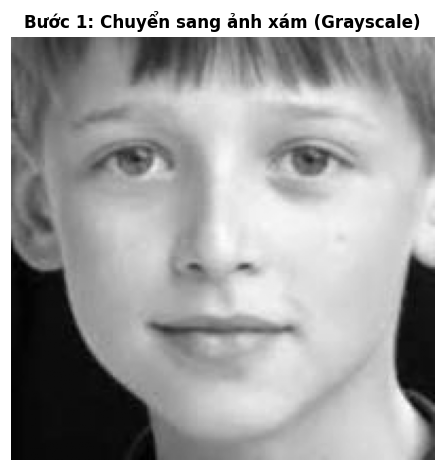

In [7]:
# Sử dụng ảnh đã resize 200x200 ở bước trước
img_gray = cv2.cvtColor(img0_resized, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title('Bước 1: Chuyển sang ảnh xám (Grayscale)', fontweight='bold')
plt.axis('off')
plt.show()

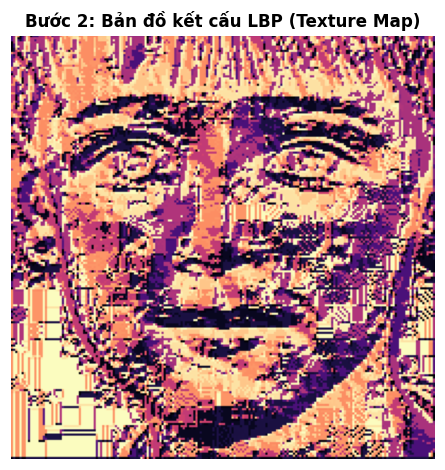

In [8]:
# Cấu hình P=8, R=1 theo features_2.py
LBP_P = 8
LBP_R = 1

# Tính toán bản đồ kết cấu
lbp_map = local_binary_pattern(img_gray, LBP_P, LBP_R, method='default')

plt.figure(figsize=(5, 5))
# Dùng colormap 'magma' để nhìn rõ các vùng kết cấu khác nhau
plt.imshow(lbp_map, cmap='magma')
plt.title('Bước 2: Bản đồ kết cấu LBP (Texture Map)', fontweight='bold')
plt.axis('off')
plt.show()

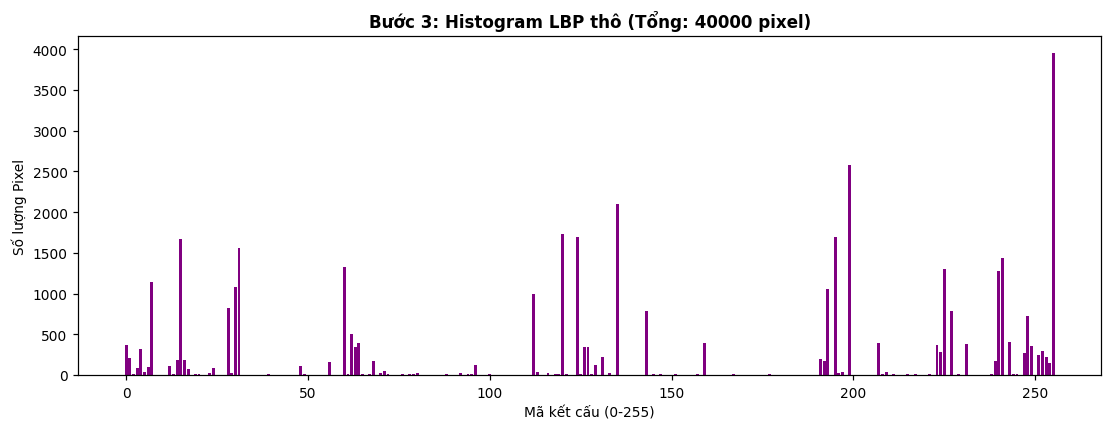

In [9]:
# Thống kê số lượng cho 256 mẫu kết cấu
lbp_hist_raw, _ = np.histogram(lbp_map.ravel(), bins=256, range=(0, 256))

plt.figure(figsize=(12, 4))
plt.bar(range(256), lbp_hist_raw, color='purple')
plt.title(f'Bước 3: Histogram LBP thô (Tổng: {int(lbp_hist_raw.sum())} pixel)', fontweight='bold')
plt.xlabel('Mã kết cấu (0-255)')
plt.ylabel('Số lượng Pixel')
plt.show()

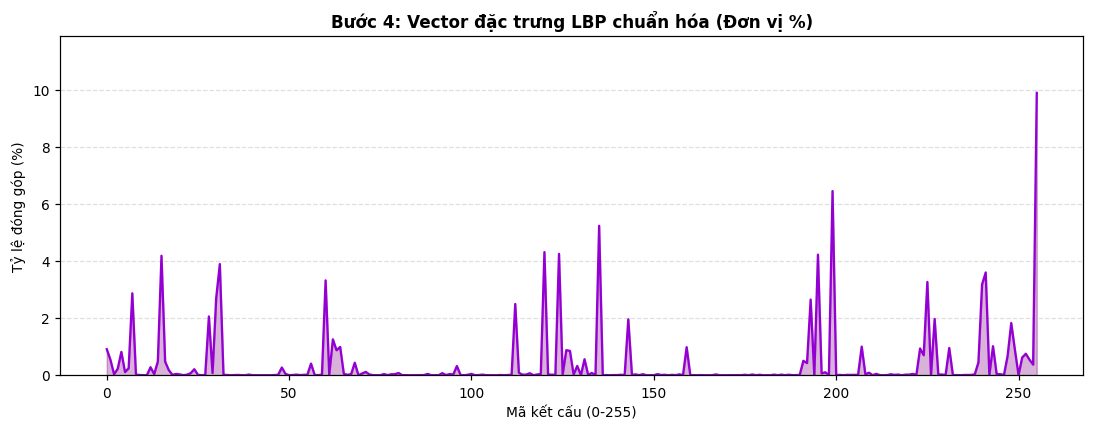

Kích thước vector đặc trưng LBP: 256 chiều


In [10]:
# Chuẩn hóa L1 (Tổng các phần tử = 1.0)
lbp_hist_norm = lbp_hist_raw.astype(np.float64)
total = lbp_hist_norm.sum()
if total > 0:
    lbp_hist_norm /= total # Đây chính là chuẩn hóa về tỷ lệ %

plt.figure(figsize=(12, 4))
# Nhân 100 để hiển thị đơn vị % trên biểu đồ
plt.plot(range(256), lbp_hist_norm * 100, color='darkviolet')
plt.fill_between(range(256), lbp_hist_norm * 100, color='purple', alpha=0.3)

plt.title('Bước 4: Vector đặc trưng LBP chuẩn hóa (Đơn vị %)', fontweight='bold')
plt.xlabel('Mã kết cấu (0-255)')
plt.ylabel('Tỷ lệ đóng góp (%)')
plt.ylim(0, max(lbp_hist_norm * 100) * 1.2) # Giới hạn trục Y cho dễ nhìn
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

print(f"Kích thước vector đặc trưng LBP: {len(lbp_hist_norm)} chiều")

---
## Đặc trưng 3 — Geometric Ratios (6 tỷ lệ hình học)

Dùng **MediaPipe Face Mesh** lấy 18 điểm key landmark, tính 6 tỷ lệ:

| Ký hiệu | Công thức | Ý nghĩa |
|---|---|---|
| R1 | dist(mắt_trái_tâm, mắt_phải_tâm) / rộng_mặt | Khoảng cách 2 mắt |
| R2 | (cao_mắt_T/rộng_mắt_T + cao_mắt_P/rộng_mắt_P) / 2 | Độ mở mắt |
| R3 | dist(sống_mũi, đầu_mũi) / cao_mặt | Chiều dài mũi |
| R4 | dist(miệng_T, miệng_P) / rộng_mặt | Chiều rộng miệng |
| R5 | dist(gò_má_T, gò_má_P) / rộng_mặt | Khoảng cách gò má |
| R6 | cao_mặt / rộng_mặt | Tỷ lệ khung mặt |

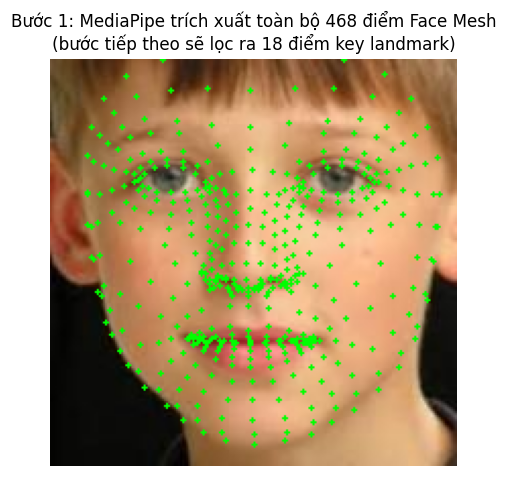

Tổng số landmark trả về: 468


In [11]:
import mediapipe as mp

# Khởi tạo MediaPipe Face Mesh
# static_image_mode=True : xử lý từng ảnh độc lập (không tracking video)
# max_num_faces=1        : chỉ phát hiện 1 khuôn mặt
# refine_landmarks=False : dùng 468 điểm chuẩn, không mở rộng thêm
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=False
)

# MediaPipe yêu cầu ảnh đầu vào ở định dạng RGB
img_rgb = cv2.cvtColor(img0_resized, cv2.COLOR_BGR2RGB)

# Chạy Face Mesh → trả về toàn bộ 468 điểm landmark cho khuôn mặt
results = face_mesh.process(img_rgb)

# Vẽ minh họa toàn bộ 468 điểm lên ảnh
# Tọa độ mỗi điểm là x, y chuẩn hóa [0,1] → nhân với kích thước ảnh để ra pixel
img_mesh = img_rgb.copy()
if results.multi_face_landmarks:
    lm = results.multi_face_landmarks[0].landmark  # mảng 468 phần tử
    for point in lm:
        x, y = int(point.x * 200), int(point.y * 200)
        cv2.circle(img_mesh, (x, y), 1, (0, 255, 0), -1)

plt.imshow(img_mesh)
plt.title(f"Bước 1: MediaPipe trích xuất toàn bộ 468 điểm Face Mesh\n(bước tiếp theo sẽ lọc ra 18 điểm key landmark)")
plt.axis('off')
plt.show()
print(f"Tổng số landmark trả về: {len(lm)}")

---
### Bước 2: Chọn 18 điểm key landmark từ 468 điểm

Từ 468 điểm của Face Mesh, chỉ **18 chỉ số cụ thể** được dùng để tính 6 tỷ lệ hình học:

| Nhóm | Chỉ số | Vai trò trong tỷ lệ |
|---|---|---|
| Mắt trái | 33 (outer), 133 (inner), 159 (top), 145 (bottom) | R1, R2 |
| Mắt phải | 263 (outer), 362 (inner), 386 (top), 374 (bottom) | R1, R2 |
| Biên mặt | 234 (trái), 454 (phải), 10 (đỉnh), 152 (cằm) | R1, R3, R4, R5, R6 |
| Mũi | 6 (sống mũi), 1 (đầu mũi) | R3 |
| Miệng | 61 (trái), 291 (phải) | R4 |
| Gò má | 93 (trái), 323 (phải) | R5 |

468 điểm còn lại bị bỏ qua.

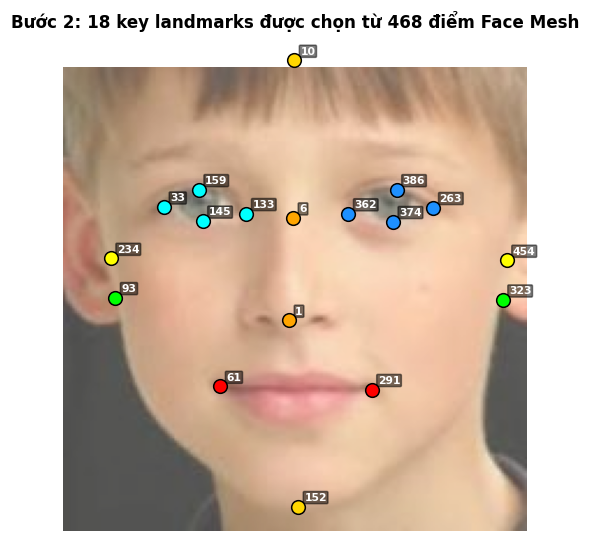

Số điểm được dùng: 18 / 468


In [23]:
# 18 chỉ số key landmark và nhãn của chúng
KEY_LANDMARKS = {
    33:  ('Mắt trái outer',  'cyan'),
    133: ('Mắt trái inner',  'cyan'),
    159: ('Mắt trái top',    'cyan'),
    145: ('Mắt trái bottom', 'cyan'),
    263: ('Mắt phải outer',  'dodgerblue'),
    362: ('Mắt phải inner',  'dodgerblue'),
    386: ('Mắt phải top',    'dodgerblue'),
    374: ('Mắt phải bottom', 'dodgerblue'),
    234: ('Mặt trái',        'yellow'),
    454: ('Mặt phải',        'yellow'),
    10:  ('Đỉnh mặt',        'gold'),
    152: ('Cằm',             'gold'),
    6:   ('Sống mũi',        'orange'),
    1:   ('Đầu mũi',         'orange'),
    61:  ('Miệng trái',      'red'),
    291: ('Miệng phải',      'red'),
    93:  ('Gò má trái',      'lime'),
    323: ('Gò má phải',      'lime'),
}

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img0_rgb, alpha=0.7)

if results.multi_face_landmarks:
    for idx, (label, color) in KEY_LANDMARKS.items():
        x = lm[idx].x * 200
        y = lm[idx].y * 200
        ax.scatter(x, y, s=80, c=color, edgecolors='black', zorder=5)
        ax.annotate(str(idx), (x, y), textcoords='offset points',
                    xytext=(4, 4), fontsize=7, color='white',
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.5))

ax.set_title('Bước 2: 18 key landmarks được chọn từ 468 điểm Face Mesh', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Số điểm được dùng: {len(KEY_LANDMARKS)} / 468")

In [29]:
if results.multi_face_landmarks:
    lm = results.multi_face_landmarks[0].landmark
    eps = 1e-10
    
    # 1. Chiều rộng và chiều cao khuôn mặt
    face_w = pt_dist(lm, 234, 454)
    face_h = pt_dist(lm, 10, 152)
    
    # 2. Khoảng cách giữa 2 tâm mắt
    lec = pt_mid(lm, 33, 133)
    rec = pt_mid(lm, 263, 362)
    eye_d = np.sqrt((lec[0]-rec[0])**2 + (lec[1]-rec[1])**2)
    
    # 3. Kích thước mắt (chiều cao / chiều rộng)
    lh, lw = pt_dist(lm, 159, 145), pt_dist(lm, 33, 133)
    rh, rw = pt_dist(lm, 386, 374), pt_dist(lm, 263, 362)
    
    # --- PHẦN BỔ SUNG: IN ĐẦY ĐỦ CÁC THÔNG SỐ THÔ ---
    print("--- CÁC THÔNG SỐ ĐO ĐẠC THÔ (RAW DISTANCES) ---")
    print(f"1. Chiều rộng mặt (face_w):   {face_w:.4f}")
    print(f"2. Chiều cao mặt (face_h):    {face_h:.4f}")
    print(f"3. Khoảng cách 2 mắt (eye_d): {eye_d:.4f}")
    print(f"4. Mắt trái (Cao {lh:.4f} / Rộng {lw:.4f})")
    print(f"5. Mắt phải (Cao {rh:.4f} / Rộng {rw:.4f})")
    print(f"6. Rộng miệng:               {pt_dist(lm, 61, 291):.4f}")
    print(f"7. Rộng gò má:               {pt_dist(lm, 93, 323):.4f}")
    print("-" * 45)

    # Sau đó mới tính toán ratios_dict như cũ
    ratios_dict = {
        'R1 - KCach 2 mat / Rong mat':   eye_d / face_w if face_w > eps else 0.0,
        'R2 - Do mo mat (TB)':           (lh/lw + rh/rw)/2 if lw>eps and rw>eps else 0.0,
        'R3 - Dai mui / Cao mat':        pt_dist(lm, 6, 1) / face_h if face_h > eps else 0.0,
        'R4 - Rong mieng / Rong mat':    pt_dist(lm, 61, 291) / face_w if face_w > eps else 0.0,
        'R5 - Rong go ma / Rong mat':    pt_dist(lm, 93, 323) / face_w if face_w > eps else 0.0,
        'R6 - Cao mat / Rong mat':       face_h / face_w if face_w > eps else 0.0,
    }

--- CÁC THÔNG SỐ ĐO ĐẠC THÔ (RAW DISTANCES) ---
1. Chiều rộng mặt (face_w):   0.8533
2. Chiều cao mặt (face_h):    0.9619
3. Khoảng cách 2 mắt (eye_d): 0.4001
4. Mắt trái (Cao 0.0684 / Rộng 0.1779)
5. Mắt phải (Cao 0.0691 / Rộng 0.1839)
6. Rộng miệng:               0.3263
7. Rộng gò má:               0.8350
---------------------------------------------


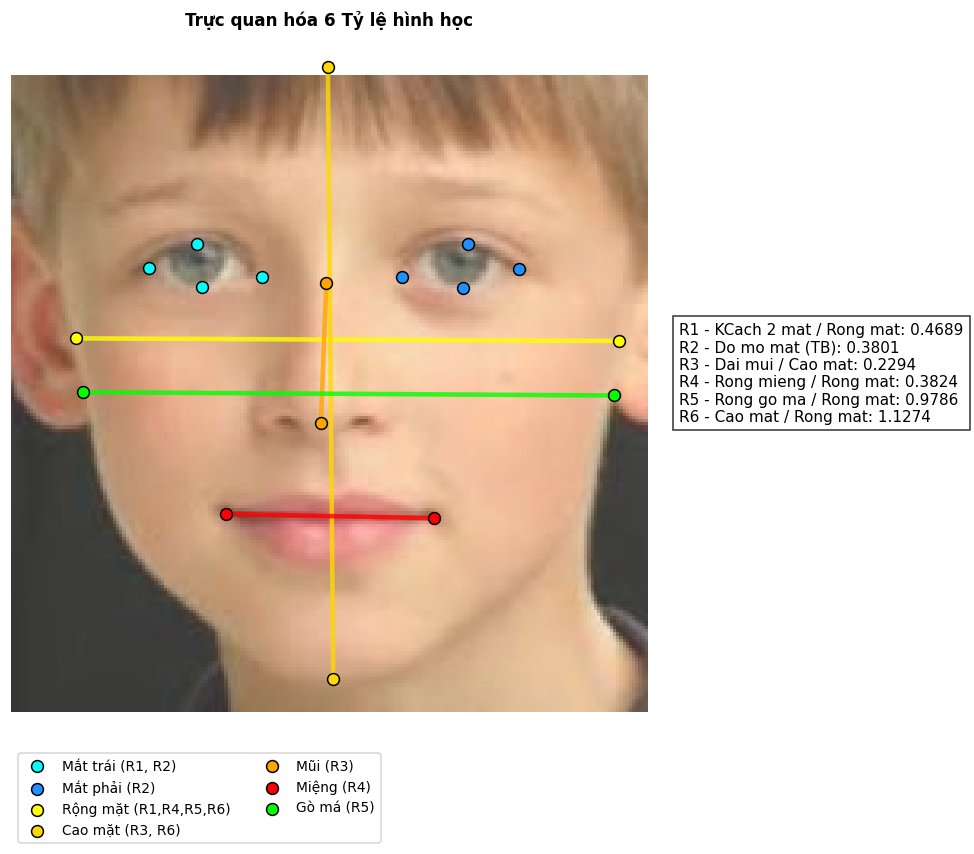

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img0_rgb, alpha=0.8)
h_img, w_img = img0_resized.shape[:2]

# Định nghĩa các nhóm điểm và màu sắc minh họa
point_defs = [
    ([33, 133, 159, 145],  'cyan',       'Mắt trái (R1, R2)'),
    ([263, 362, 386, 374], 'dodgerblue', 'Mắt phải (R2)'),
    ([234, 454],           'yellow',     'Rộng mặt (R1,R4,R5,R6)'),
    ([10, 152],            'gold',       'Cao mặt (R3, R6)'),
    ([6, 1],               'orange',     'Mũi (R3)'),
    ([61, 291],            'red',        'Miệng (R4)'),
    ([93, 323],            'lime',       'Gò má (R5)'),
]

# Vẽ các điểm và đường nối
for idxs, color, label in point_defs:
    kx = [lm[i].x * w_img for i in idxs]
    ky = [lm[i].y * h_img for i in idxs]
    ax.scatter(kx, ky, s=60, c=color, edgecolors='black', label=label, zorder=5)
    if len(idxs) == 2:
        ax.plot(kx, ky, color=color, lw=3, alpha=0.8)

# Hiển thị bảng giá trị tỉ lệ bên cạnh ảnh
ratio_text = '\n'.join([f'{k}: {v:.4f}' for k, v in ratios_dict.items()])
ax.text(1.05, 0.5, ratio_text, transform=ax.transAxes, fontsize=10, 
        verticalalignment='center', bbox=dict(facecolor='white', alpha=0.8))

ax.set_title('Trực quan hóa 6 Tỷ lệ hình học', fontweight='bold')
ax.axis('off')
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=2)
plt.show()